### [ 손글씨 숫자 0 ~ 9 인식 및 분류 모델 학습 ]

- 데이터 관련 
    * 로딩 및 기본 확인 : EDA
    * 전처리 진행
    * 데이터 가공 (통계치 X)

- 학습 관련
    * 피쳐, 타겟 분리
    * 데이터셋 분리 : 학습용/검증용/테스트용
    * 데이터 가공 -> 데이터 누수 예방
    * 학습/검증/테스트 함수 

- 학습 진행
    * 학습 관련 설정값 <= 하이퍼파라미터들
    * 학습 관련 인스턴스들
    * 학습 진행 + 진행 과정에 대한 로그 : 학습과 검증의 loss, score 등등 
    
- 학습 평가
    * 학습 과정 로그기반 시각화 
    * 과대/과소/최적 평가


>> **[1] 데이터 관련**

In [1]:
## ---------------------------------------------------------
## 모듈로딩
## ---------------------------------------------------------
## => MNIST 모델 클래스와 데이터셋 클래스
import sys 
sys.path.append(r'D:\KDT\VS_KDT_14\[9]_DL\DAY04')
from ex01_mnist_class import *

## [임시방편] libiomp5md.dll 중복 로드되며 프로그램 충돌
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

## => 데이터 관련 모듈들
import pandas as pd 
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

In [2]:
#%pip install memory_profiler

In [3]:
from memory_profiler import memory_usage
print(f"{memory_usage()[0]:.2f} MiB")

585.14 MiB


In [4]:
## => 학습용, 테스트용 데이터 파일 설정
TRAIN_FILE = '../Data/mnist/mnist_train.csv'
TEST_FILE  = '../Data/mnist/mnist_test.csv'

import os
print(f"{os.path.getsize(TRAIN_FILE) / (1024**2):.2f} MB")
print(f"{os.path.getsize(TEST_FILE) / (1024**2):.2f} MB")

104.50 MB
17.44 MB


In [5]:
## => 메모리 사용량 체크
import gc
gc.collect()

print("읽기 시작 전")
import psutil
print(f"{psutil.virtual_memory().available / (1024**3):.2f} GiB 사용가능")

trainDF = pd.read_csv(TRAIN_FILE, header=None, dtype='uint8')
print("train 로딩 완료")
print(f"{psutil.virtual_memory().available / (1024**3):.2f} GiB 사용가능")

testDF = pd.read_csv(TEST_FILE, header=None, dtype='uint8')
print("test 로딩 완료")

읽기 시작 전
13.64 GiB 사용가능
train 로딩 완료
13.23 GiB 사용가능
test 로딩 완료


In [6]:
## => 데이터 로딩 : 첫 번째 줄 컬럼명 X => header=None 설정
trainDF = pd.read_csv(TRAIN_FILE, header=None, dtype='uint8')
testDF  = pd.read_csv(TEST_FILE,  header=None, dtype='uint8')

print(f'[Train] {trainDF.shape}   [Test] {testDF.shape} ')

[Train] (60000, 785)   [Test] (10000, 785) 


In [7]:
## => train/test의 첫번째 행 데이터 추출 후 시각화 
train_row0 = trainDF.iloc[0]
train_label, train_data = train_row0[0], train_row0[1:].values.reshape(28, 28)

test_row0 = testDF.iloc[0]
test_label, test_data = test_row0[0], test_row0[1:].values.reshape(28, 28)

print(f'[train_label] {train_label}   [train_data] {train_data.shape}')
print(f'[test_label]  {test_label}   [test_data]  {test_data.shape}')

[train_label] 5   [train_data] (28, 28)
[test_label]  7   [test_data]  (28, 28)


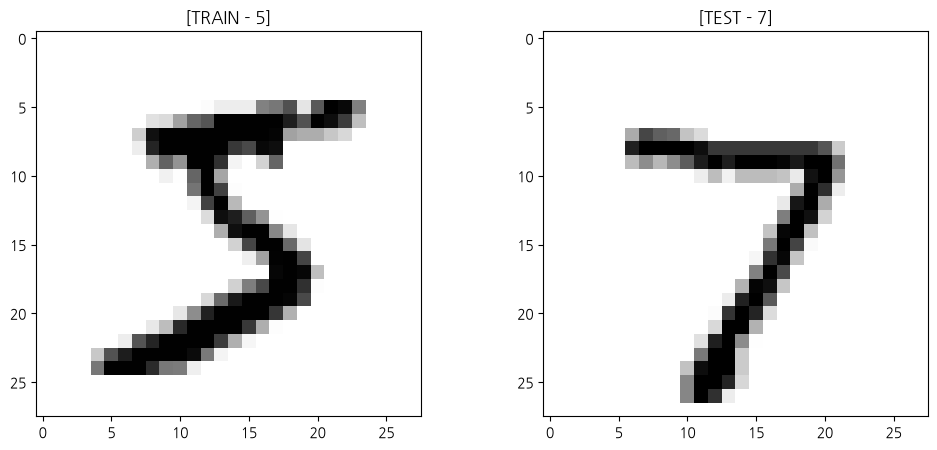

In [8]:
## => 라벨과 이미지 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

titles  = ['TRAIN', 'TEST']
labels  = [train_label, test_label]
datas   = [train_data, test_data]

for ax, title, label, img_data in zip( axes, titles, labels, datas ):
    ax.imshow(img_data, cmap='gray_r')
    ax.set_title(f'[{title} - {label}]')

plt.show()


>> **[2] 학습관련 : 피쳐/타겟 분리, 데이터셋 분리**

In [9]:
## --------------------------------------------------------
## 모듈 로딩
## --------------------------------------------------------
from sklearn.model_selection import train_test_split


In [10]:
## --------------------------------------------------------
## 피쳐와 타겟 분리
## --------------------------------------------------------
featureDF = trainDF[trainDF.columns[1:]]
targetSR  = trainDF[trainDF.columns[0]]

featureTDF = testDF[testDF.columns[1:]]
targetTSR  = testDF[testDF.columns[0]]

print(f'[Train] {featureDF.shape}, {targetSR.shape}, {targetSR.value_counts(normalize=True).round(1).tolist()}')
print(f'[Test]  {featureTDF.shape}, {targetTSR.shape}, {targetTSR.value_counts(normalize=True).round(1).tolist()}')


[Train] (60000, 784), (60000,), [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
[Test]  (10000, 784), (10000,), [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]


In [11]:
## --------------------------------------------------------
## 학습용 | 테스트용 ==> 학습용 | 검증용 : train, test 데이터 분리
## 학습용 : 검증용 = 8 : 2
## --------------------------------------------------------  
X_train, X_valid, Y_train, Y_valid = train_test_split(featureDF,
                                                      targetSR,
                                                      test_size=0.15,
                                                      random_state=42,
                                                      stratify=targetSR)


In [12]:
## 학습용 / 검증용 => 피쳐, 타겟, 클래스별 비율
print(f'[Train] {X_train.shape}, {Y_train.shape}, {Y_train.value_counts(normalize=True).round(1).tolist()}')
print(f'[Valid] {X_valid.shape}, {Y_valid.shape}, {Y_valid.value_counts(normalize=True).round(1).tolist()}')


[Train] (51000, 784), (51000,), [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
[Valid] (9000, 784), (9000,), [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]


>> **[3] 학습 준비 : 설정값, 인스턴스들, 학습관련 함수들**

In [13]:
## ----------------------------------------------------------
## 모듈 로딩
## ----------------------------------------------------------
## => 학습관련 사용자 정의 함수들
sys.path.append(r'D:\KDT\VS_KDT_14\[9]_DL\DAY04')
from dl_func import *

# => 최적화, 손실함수, 데이터로더 관련 모듈
from torch.optim import Adam 
from torch.nn import CrossEntropyLoss 
from torch.utils.data import DataLoader 
import torch 


In [ ]:
## ----------------------------------------------------------
## 학습 진행 관련 설정들
## ----------------------------------------------------------
## => 처음~끝까지 학습 횟수
EPOCHS = 1000

## => 학습량 크기
BS = 500

## => W,B 업데이트/값 보정 간격
LR = 0.001

## => 학습 위치 
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE => {DEVICE}')

In [ ]:
## ----------------------------------------------------------
## 체크포인트/모델 저장 관련 설정
## ----------------------------------------------------------
import os

## => 모델/체크포인트 저장 폴더
SAVE_PATH = '../Models/mnist/'
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

## => best 모델 저장 파일 (가중치만, 추론용)
SAVE_MODEL = SAVE_PATH + 'model_best.pth'

## => 학습 재개용 체크포인트 파일 (model + optimizer + epoch 등)
SAVE_CKPT  = SAVE_PATH + 'model_checkpoint.pth'

## => 검증 손실이 개선되지 않아도 봐줄 기준 횟수 (조기 종료 기준)
BREAK_CNT_STD = 10

In [23]:
## ----------------------------------------------------------
## 인스턴스 생성
## ----------------------------------------------------------
## => 모델 인스턴스 생성 + 저장 위치 설정
model = MNISTClassifier().to(DEVICE)

## => 최적화 인스턴스
adamOP = Adam(model.parameters(), lr=LR)

## => 손실함수 인스턴스 
lossFN = CrossEntropyLoss()

## => 데이터로더 인스턴스
## => train : valid : test = 51000, 9000, 10000
trainDL = DataLoader( MNISTDataset(X_train, Y_train), batch_size=BS, shuffle=True )
validDL = DataLoader( MNISTDataset(X_valid, Y_valid), batch_size=BS )
testDL  = DataLoader( MNISTDataset(featureTDF, targetTSR), batch_size=BS )


>> **[체크포인트(Checkpoint) 개념]**

학습에 1000 에포크(EPOCHS)가 걸리는데, 중간에 커널이 죽거나 학습을 멈춰야 하는 상황이 생길 수 있습니다.  
**체크포인트**는 이런 상황에 대비해 학습 중간 상태를 파일로 저장해두는 것입니다.

- **best 모델** (`SAVE_MODEL`) : 검증 손실(`v_loss`)이 가장 낮았을 때의 `model.state_dict()`만 저장 → 나중에 추론/테스트에 사용
- **체크포인트** (`SAVE_CKPT`) : 매 에포크마다 `model`, `optimizer`, `epoch`, `epochHist`를 함께 저장 → 학습이 끊겨도 그 지점부터 이어서 학습 가능

```
[매 에포크] model, optimizer, epoch, epochHist ─▶ SAVE_CKPT (last checkpoint, 항상 갱신)
[검증개선시] model.state_dict()                  ─▶ SAVE_MODEL (best model, 개선될 때만 갱신)
```

아래 설정 셀과 학습 루프에 이 두 가지 저장 로직을 추가합니다. 개선 없이 `BREAK_CNT_STD`회 이상 지속되면 조기 종료(early stopping)도 함께 넣었습니다.


In [ ]:
## ----------------------------------------------------------
## 학습 진행
## ----------------------------------------------------------
## 에포크 단위 손실과 정확도 저장 변수
epochHist = {'T_LOSS':[], 'T_ACC':[], 'V_LOSS':[],  'V_ACC':[]}

## => 체크포인트/조기종료 관련 변수
BEST_LOSS = float('inf')     ## 검증 손실 최저값 저장
BREAK_CNT = 0                ## 검증 손실이 개선되지 않은 횟수

for epo in range(EPOCHS+1):

    t_loss, t_acc = training(model, trainDL, lossFN, adamOP, X_train.shape[0], DEVICE)
    v_loss, v_acc = evaluating(model, validDL, lossFN, X_valid.shape[0], DEVICE)

    for key, value in zip(epochHist.keys(), [t_loss, t_acc, v_loss, v_acc]):
        epochHist[key].append(value)

    ## --------------------------------------------------------
    ## (1) 체크포인트 저장 : 매 에포크마다 최신 상태 저장
    ##     -> 학습이 중단되어도 이 지점부터 이어서 학습 가능
    ## --------------------------------------------------------
    torch.save({
        'epoch': epo,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': adamOP.state_dict(),
        'epochHist': epochHist,
    }, SAVE_CKPT)

    ## --------------------------------------------------------
    ## (2) best 모델 저장 : 검증 손실이 개선됐을 때만 저장
    ##     -> 조기종료 카운트도 이때 초기화
    ## --------------------------------------------------------
    if v_loss < BEST_LOSS:
        BEST_LOSS = v_loss
        BREAK_CNT = 0
        torch.save(model.state_dict(), SAVE_MODEL)
    else:
        BREAK_CNT += 1

    if not epo % 10:
        print(f'[EPOCH-{epo:04}] TRAIN : Loss {t_loss:.6f}  Acc {t_acc:.6f}   '
              f'VALID : Loss {v_loss:.6f}  Acc {v_acc:.6f}   '
              f'BEST_LOSS {BEST_LOSS:.6f}  BREAK_CNT {BREAK_CNT}')

    ## --------------------------------------------------------
    ## (3) 조기 종료(Early Stopping)
    ##     -> BREAK_CNT_STD회 연속 개선 없으면 학습 중단
    ## --------------------------------------------------------
    if BREAK_CNT >= BREAK_CNT_STD:
        print(f'[EPOCH-{epo:04}] 검증 성능 개선 없음 -> 학습 조기 종료!')
        break

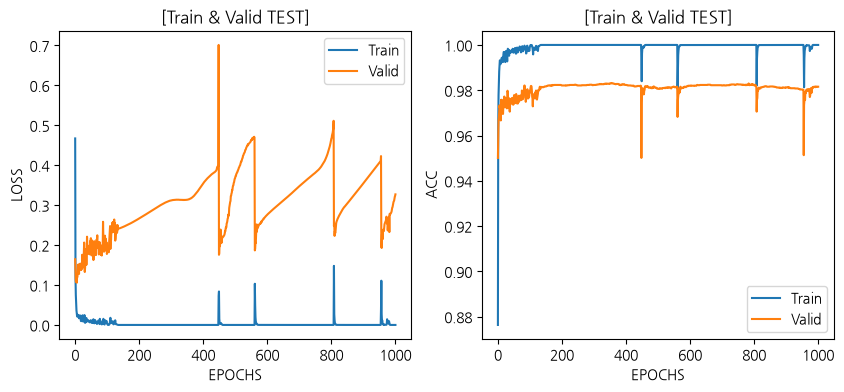

In [26]:
## ======================================================
## 시각화
## ======================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, key in zip(axes, ['LOSS', 'ACC']):

    ax.plot(epochHist[f'T_{key}'], label = 'Train')
    ax.plot(epochHist[f'V_{key}'], label = 'Valid')

    ax.set_title(f"[Train & Valid {title}]")
    ax.set_xlabel("EPOCHS")
    ax.set_ylabel(f"{key}")
    ax.legend()
plt.show()

>> **[4] 테스트 진행**

In [27]:
## ----------------------------------------------------------
## 테스트 진행
## ----------------------------------------------------------
loss, acc = evaluating(model, testDL, lossFN, featureTDF.shape[0], DEVICE)

print(f'[TEST] Loss {loss:.6f}  Acc {acc:.6f} ')
    

[TEST] Loss 0.317119  Acc 0.981400 


>> **[5] 저장된 모델/체크포인트 활용**

- 커널을 새로 켜거나 다른 스크립트에서 **추론만** 할 경우 → best 모델(`SAVE_MODEL`)만 불러오면 충분
- 학습이 중단되어 **이어서 학습**해야 할 경우 → 체크포인트(`SAVE_CKPT`)에서 model, optimizer, epoch, epochHist까지 복원


In [ ]:
## ----------------------------------------------------------
## (A) best 모델만 불러와서 추론/테스트에 사용
## ----------------------------------------------------------
best_model = MNISTClassifier().to(DEVICE)
best_model.load_state_dict(torch.load(SAVE_MODEL, map_location=DEVICE))

loss, acc = evaluating(best_model, testDL, lossFN, featureTDF.shape[0], DEVICE)
print(f'[BEST MODEL - TEST] Loss {loss:.6f}  Acc {acc:.6f}')

In [ ]:
## ----------------------------------------------------------
## (B) 체크포인트를 불러와서 학습 재개 (예시)
##     -> 아래 코드는 학습을 중단했다가 다시 이어갈 때 사용
## ----------------------------------------------------------
resume_model = MNISTClassifier().to(DEVICE)
resume_optim = Adam(resume_model.parameters(), lr=LR)

checkpoint = torch.load(SAVE_CKPT, map_location=DEVICE, weights_only=False)

resume_model.load_state_dict(checkpoint['model_state_dict'])
resume_optim.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
resume_epochHist = checkpoint['epochHist']

print(f'체크포인트 복원 완료 -> {start_epoch} 에포크부터 이어서 학습 가능')

## 이어서 학습하려면 위의 학습 루프에서
## for epo in range(start_epoch, EPOCHS+1): 로 시작 지점만 바꿔서 재실행하면 됩니다.